# Exploratory Data Analysis

## Project Topic

The impact of AI adoption on productivity, job satisfaction, work-life balance, burnout, and career outcomes.

### Main Research Question

How can AI be used in a way that maximizes professional benefits while minimizing negative effects on employee wellbeing?

This notebook explores the cleaned Global AI workplace dataset. The focus is on identifying patterns between AI usage, productivity, wellbeing, and employee attitudes toward AI.

The findings are interpreted cautiously because several relationships in this dataset are relatively weak.

In [89]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

df = pd.read_csv("../data/processed/global_ai_master.csv")

df.head()

,respondent_id,survey_year,age,gender,country,education_level,job_role,industry,company_size,years_of_experience,remote_work_status,annual_salary_usd,salary_change_yoy_pct,job_satisfaction_score,career_growth_outlook,ai_job_replacement_fear,job_search_status,received_ai_related_promotion,work_life_balance_score,burnout_level,skills,num_skills,top_certification,weekly_learning_hours,primary_learning_platform,learned_genai_skills_2024_2026,employer_provides_ai_training,company_has_ai_policy,ai_bias_concern_level,data_privacy_concern_level,supports_ai_regulation,has_experienced_ai_misuse,trust_in_ai_decisions,num_ai_tools,avg_usage_frequency,avg_productivity_change_pct,avg_tool_satisfaction
0,R00001,2025,30,Male,Nigeria,PhD,Data Analyst,E-commerce,1001-5000,10,Fully Remote,63700,9.00,4,Neutral,Unlikely,Open to offers,No,1,Mild,Computer Vision; Feature Engineering; Python; ...,9,No Certification,3,Fast.ai,Yes,Partially,No,5,5,Neutral,No,Low,4,2.75,22.38,3.75
1,R00002,2025,36,Female,Spain,Master's,Data Analyst,Legal,5000+,6,On-site,124600,15.10,1,Positive,Somewhat likely,Recently changed,Yes,5,Mild,SQL; Graph Neural Networks; Generative AI; Fea...,10,No Certification,8,Self-study (books/papers),Yes,No,Don't know,3,1,Agree,No,High,5,3.20,24.06,4.00
2,R00003,2025,18,Male,Spain,High School,AI Ethics / Policy,Technology,5000+,11,Fully Remote,39800,5.20,3,Negative,Very likely,Not looking,No,4,Severe,Python; Prompt Engineering; PyTorch; Spark; R;...,8,AWS ML Specialty,8,Kaggle Learn,Yes,No,Yes - formal,5,5,Strongly agree,Unsure,Moderate,1,4.00,45.30,4.00
3,R00004,2024,31,Female,India,Bachelor's,Full-Stack Developer,Telecom,5000+,21,Fully Remote,65400,2.20,4,Very positive,Unlikely,Recently changed,No,3,Moderate,Azure; Time Series Analysis; R; Scikit-learn; ...,6,AWS ML Specialty,12,University courses,Yes,Yes,No,3,4,Agree,No,Low,4,4.50,21.20,4.00
4,R00005,2026,34,Female,Nigeria,Master's,Data Scientist,Media & Entertainment,1-10,6,On-site,53800,20.40,2,Positive,Very likely,Actively looking,Yes,4,Severe,Time Series Analysis; R; PyTorch; Fine-tuning ...,9,TensorFlow Developer Certificate,15,University courses,No,No,Yes - informal,3,3,Agree,Unsure,High,2,4.50,37.60,3.50


# 1. Dataset Overview

The first step is to inspect the size, structure, missing values, and general characteristics of the dataset.

In [90]:
# Display dataset dimensions

df.shape

(12000, 37)

In [91]:
# Review data structure and variable types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   12000 non-null  str    
 1   survey_year                     12000 non-null  int64  
 2   age                             12000 non-null  int64  
 3   gender                          12000 non-null  str    
 4   country                         12000 non-null  str    
 5   education_level                 12000 non-null  str    
 6   job_role                        12000 non-null  str    
 7   industry                        12000 non-null  str    
 8   company_size                    12000 non-null  str    
 9   years_of_experience             12000 non-null  int64  
 10  remote_work_status              12000 non-null  str    
 11  annual_salary_usd               12000 non-null  int64  
 12  salary_change_yoy_pct           12000 non-n

In [92]:
# Check missing values before burnout preprocessing

missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

## Burnout Preprocessing Decision

The only remaining empty values are in `burnout_level`. In this project, these empty values are interpreted as **No burnout**. The dataset appears to use blank burnout entries to represent respondents who did not report burnout symptoms.

In [93]:
# Treat empty burnout values as a meaningful category

df["burnout_level"] = df["burnout_level"].fillna("No burnout")

df["burnout_level"] = pd.Categorical(
    df["burnout_level"],
    categories=["No burnout", "Mild", "Moderate", "Severe"],
    ordered=True
)

df["burnout_level"].value_counts()

burnout_level
Mild          4158
Moderate      3703
No burnout    2414
Severe        1725
Name: count, dtype: int64

In [94]:
# Verify that no missing values remain

missing_values_after = df.isna().sum().sort_values(ascending=False)
missing_values_after[missing_values_after > 0]

Series([], dtype: int64)

In [95]:
# Generate descriptive statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
survey_year,12000.00,2024.91,0.76,2024.00,2024.00,2025.00,2026.00,2026.00
age,12000.00,31.58,7.68,18.00,26.00,31.00,37.00,61.00
years_of_experience,12000.00,8.77,6.74,0.00,4.00,7.00,11.00,35.00
annual_salary_usd,12000.00,112710.47,75454.20,5000.00,50200.00,99600.00,160700.00,566800.00
salary_change_yoy_pct,12000.00,5.08,8.10,-25.00,-0.30,5.00,10.50,36.80
job_satisfaction_score,12000.00,3.63,1.12,1.00,3.00,4.00,4.00,5.00
work_life_balance_score,12000.00,3.48,1.12,1.00,3.00,4.00,4.00,5.00
num_skills,12000.00,8.04,2.77,3.00,6.00,8.00,10.00,15.00
weekly_learning_hours,12000.00,7.71,4.70,0.00,4.00,8.00,11.00,30.00
ai_bias_concern_level,12000.00,3.55,1.12,1.00,3.00,4.00,4.00,5.00


### Initial observations

The dataset contains 12,000 rows and 37 columns. After preprocessing `burnout_level`, no relevant missing values remain.

The dataset includes demographic information, job-related variables, AI usage indicators, productivity metrics, salary information, and attitudes toward AI.

# 2. Workforce Profile

This section describes the composition of the dataset by industry, job role, education level, company size, and country.

In [96]:
# Display industry distribution as percentages

industry_counts = df["industry"].value_counts(normalize=True).mul(100).round(2)
industry_counts

industry
Technology              22.37
Finance & Banking       14.16
Healthcare               9.69
E-commerce               9.20
Education                7.82
Manufacturing            6.28
Consulting               5.27
Media & Entertainment    4.93
Telecom                  3.92
Government               3.78
Energy                   2.93
Retail                   2.88
Automotive               2.87
Agriculture              2.04
Legal                    1.86
Name: proportion, dtype: float64

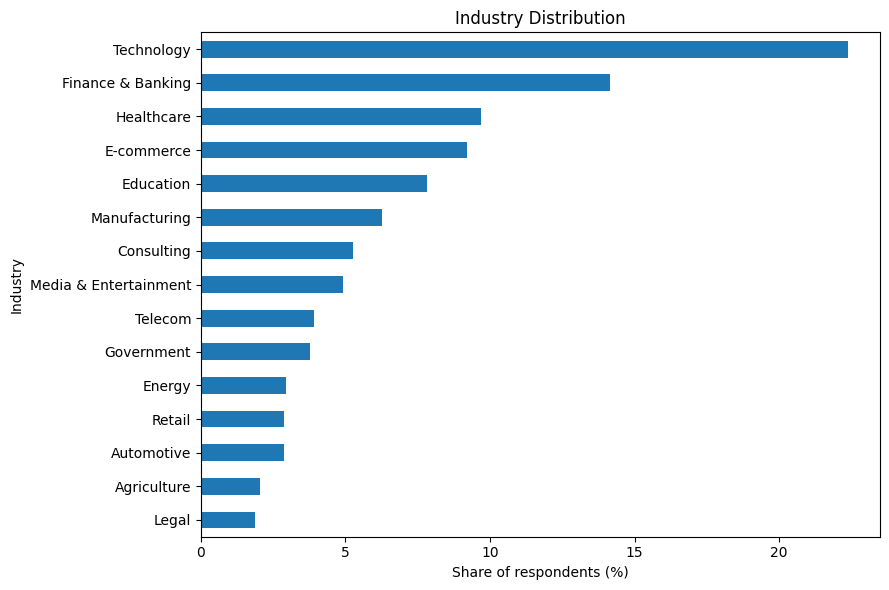

In [97]:
# Visualize industry distribution

industry_counts.sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Industry Distribution")
plt.xlabel("Share of respondents (%)")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

In [98]:
# Display the most common job roles

job_role_counts = df["job_role"].value_counts(normalize=True).mul(100).round(2)
job_role_counts.head(10)

job_role
Data Scientist            14.07
ML Engineer               12.59
Software Engineer         12.58
Data Analyst               9.53
Full-Stack Developer       7.94
Product Manager            7.36
AI Researcher              6.11
Data Engineer              6.09
Business Analyst           5.88
DevOps / MLOps Engineer    4.72
Name: proportion, dtype: float64

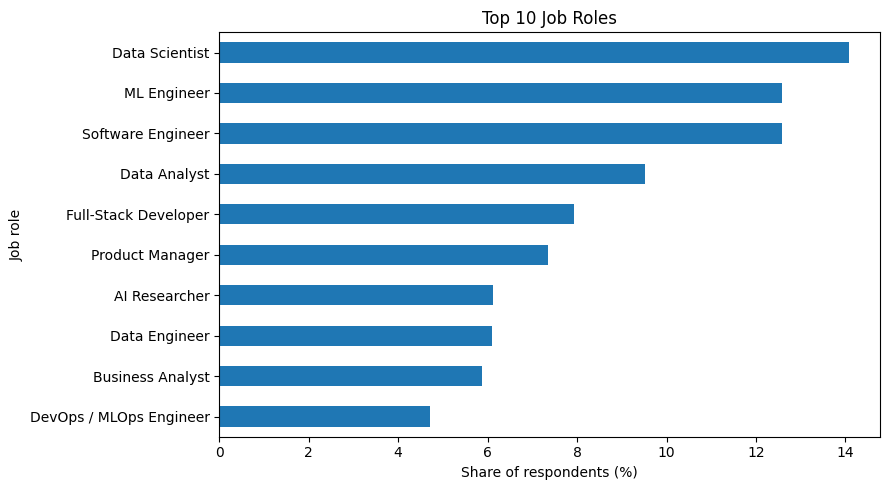

In [99]:
# Visualize the most common job roles

job_role_counts.head(10).sort_values().plot(kind="barh", figsize=(9, 5))
plt.title("Top 10 Job Roles")
plt.xlabel("Share of respondents (%)")
plt.ylabel("Job role")
plt.tight_layout()
plt.show()

In [100]:
# Display education level distribution

education_counts = df["education_level"].value_counts(normalize=True).mul(100).round(2)
education_counts

education_level
Master's                 40.33
Bachelor's               29.75
Self-taught / Bootcamp   14.66
PhD                      12.42
High School               2.84
Name: proportion, dtype: float64

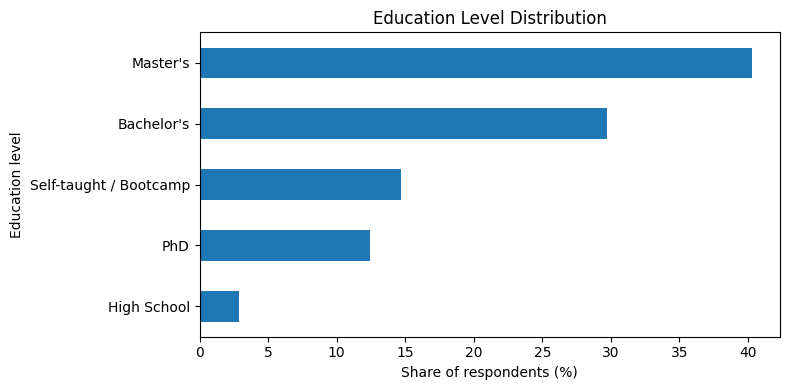

In [101]:
# Visualize education level distribution

education_counts.sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Education Level Distribution")
plt.xlabel("Share of respondents (%)")
plt.ylabel("Education level")
plt.tight_layout()
plt.show()

### Workforce profile interpretation

The dataset is strongly represented by technology-related roles and industries. Technology is the largest industry group, and data- or software-related roles are among the most frequent job roles.

This is important for interpretation: the dataset should not be treated as a fully balanced representation of all professions.

# 3. AI Adoption Analysis

This section explores how intensively employees use AI tools and how much time they spend learning AI-related skills.

In [102]:
# Summarize AI usage variables

df[["num_ai_tools", "avg_usage_frequency", "weekly_learning_hours", "num_skills"]].describe().T

,count,mean,std,min,25%,50%,75%,max
num_ai_tools,12000.00,3.93,1.82,1.00,3.00,4.00,5.00,8.00
avg_usage_frequency,12000.00,3.44,0.75,1.00,3.00,3.50,4.00,5.00
weekly_learning_hours,12000.00,7.71,4.70,0.00,4.00,8.00,11.00,30.00
num_skills,12000.00,8.04,2.77,3.00,6.00,8.00,10.00,15.00


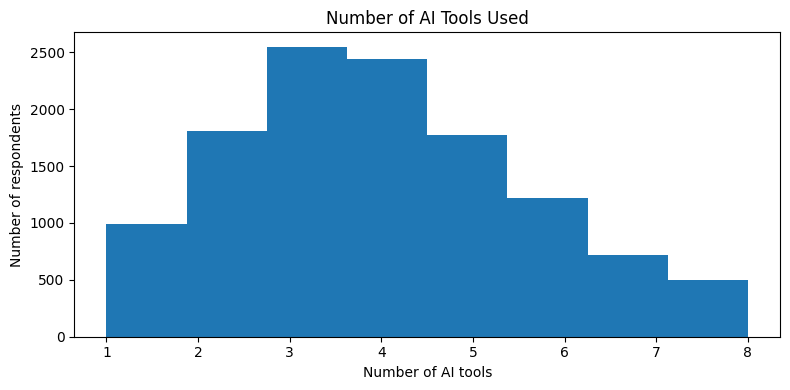

In [103]:
# Visualize the number of AI tools used

df["num_ai_tools"].plot(kind="hist", bins=8, figsize=(8, 4))
plt.title("Number of AI Tools Used")
plt.xlabel("Number of AI tools")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

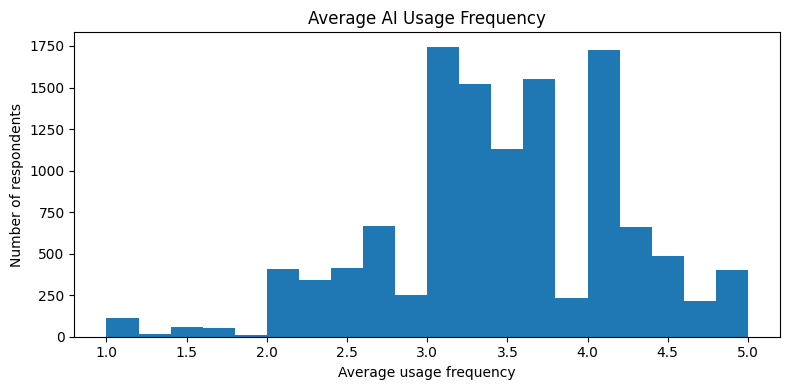

In [104]:
# Visualize average AI usage frequency

df["avg_usage_frequency"].plot(kind="hist", bins=20, figsize=(8, 4))
plt.title("Average AI Usage Frequency")
plt.xlabel("Average usage frequency")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

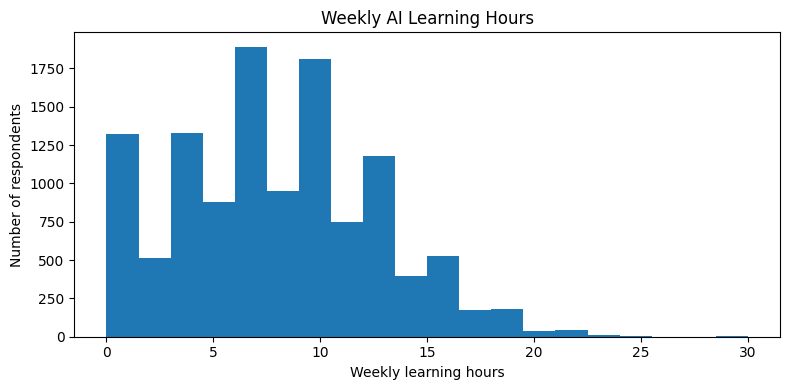

In [105]:
# Visualize weekly learning hours

df["weekly_learning_hours"].plot(kind="hist", bins=20, figsize=(8, 4))
plt.title("Weekly AI Learning Hours")
plt.xlabel("Weekly learning hours")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

### AI adoption interpretation

The dataset suggests that respondents are actively exposed to AI tools and AI-related learning. However, this section is descriptive only. It does not yet show whether AI usage is connected to productivity or career outcomes.

# 4. Productivity Analysis

This section checks whether AI usage, number of AI tools, and AI skills are associated with productivity change.

In [106]:
# Summarize productivity change

df["avg_productivity_change_pct"].describe()

count   12000.00
mean       30.21
std        11.55
min       -20.00
25%        23.26
50%        30.18
75%        37.12
max        80.00
Name: avg_productivity_change_pct, dtype: float64

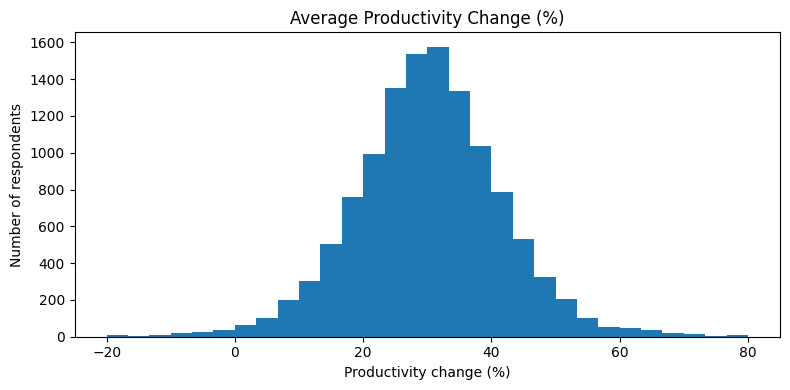

In [107]:
# Visualize productivity change distribution

df["avg_productivity_change_pct"].plot(kind="hist", bins=30, figsize=(8, 4))
plt.title("Average Productivity Change (%)")
plt.xlabel("Productivity change (%)")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

In [108]:
# Create quartile-based AI usage groups

df["usage_group"] = pd.qcut(
    df["avg_usage_frequency"],
    q=4,
    labels=["Low", "Medium-low", "Medium-high", "High"]
)

usage_productivity = df.groupby("usage_group", observed=False)[
    ["avg_productivity_change_pct", "job_satisfaction_score", "work_life_balance_score"]
].mean().round(2)

usage_productivity

,avg_productivity_change_pct,job_satisfaction_score,work_life_balance_score
usage_group,,,
Low,30.23,3.63,3.50
Medium-low,30.16,3.60,3.49
Medium-high,30.06,3.63,3.45
High,30.53,3.66,3.50


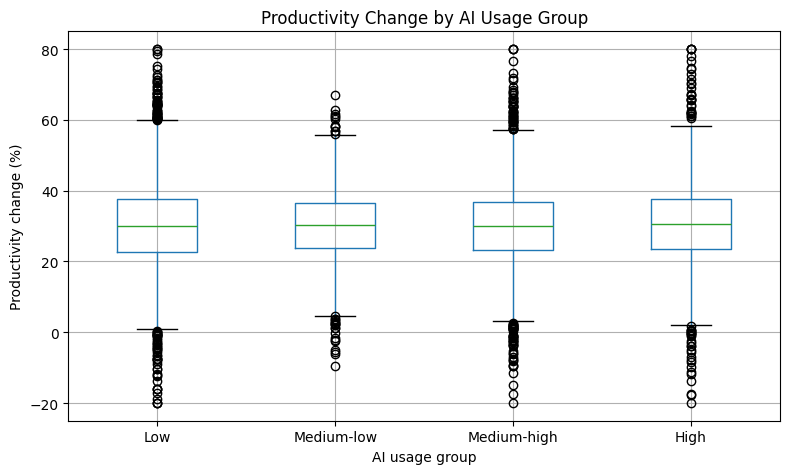

In [109]:
# Compare productivity change across AI usage groups

df.boxplot(
    column="avg_productivity_change_pct",
    by="usage_group",
    figsize=(8, 5)
)
plt.title("Productivity Change by AI Usage Group")
plt.suptitle("")
plt.xlabel("AI usage group")
plt.ylabel("Productivity change (%)")
plt.tight_layout()
plt.show()

In [110]:
# Calculate correlations with productivity change

productivity_corr = df.select_dtypes(include="number").corr()["avg_productivity_change_pct"].sort_values(ascending=False)
productivity_corr.round(3)

avg_productivity_change_pct    1.00
work_life_balance_score        0.03
job_satisfaction_score         0.01
avg_tool_satisfaction          0.01
data_privacy_concern_level     0.01
annual_salary_usd              0.01
years_of_experience            0.00
salary_change_yoy_pct          0.00
avg_usage_frequency            0.00
weekly_learning_hours          0.00
age                           -0.00
ai_bias_concern_level         -0.01
survey_year                   -0.01
num_ai_tools                  -0.01
num_skills                    -0.02
Name: avg_productivity_change_pct, dtype: float64

### Productivity interpretation

The average reported productivity change is around 30%. However, the relationship between AI usage frequency and productivity is very weak.

The comparison by AI usage groups shows only minimal differences. The highest AI usage group has only a slightly higher average productivity change, but the overall pattern is not strong.

The correlation between `avg_usage_frequency` and `avg_productivity_change_pct` is close to zero. Therefore, this dataset does not provide strong evidence that more frequent AI usage is associated with higher productivity gains.

# 5. Career Development and Salary

This section examines whether AI skills, AI-related promotions, and salary growth are connected.

In [111]:
# Summarize salary and salary growth

df[["annual_salary_usd", "salary_change_yoy_pct", "num_skills"]].describe().T

,count,mean,std,min,25%,50%,75%,max
annual_salary_usd,12000.00,112710.47,75454.20,5000.00,50200.00,99600.00,160700.00,566800.00
salary_change_yoy_pct,12000.00,5.08,8.10,-25.00,-0.30,5.00,10.50,36.80
num_skills,12000.00,8.04,2.77,3.00,6.00,8.00,10.00,15.00


In [112]:
# Compare salary and salary growth by AI-related promotion status

promotion_summary = df.groupby("received_ai_related_promotion")[
    ["annual_salary_usd", "salary_change_yoy_pct", "num_skills", "num_ai_tools", "avg_productivity_change_pct"]
].mean().round(2)

promotion_summary

,annual_salary_usd,salary_change_yoy_pct,num_skills,num_ai_tools,avg_productivity_change_pct
received_ai_related_promotion,,,,,
No,112965.51,5.05,8.02,3.92,30.19
Yes,111818.81,5.17,8.13,4.00,30.31


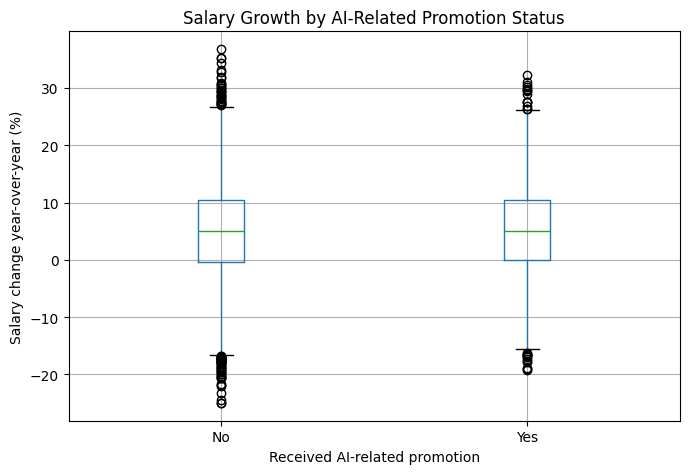

In [113]:
# Visualize salary growth by AI-related promotion status

df.boxplot(
    column="salary_change_yoy_pct",
    by="received_ai_related_promotion",
    figsize=(7, 5)
)
plt.title("Salary Growth by AI-Related Promotion Status")
plt.suptitle("")
plt.xlabel("Received AI-related promotion")
plt.ylabel("Salary change year-over-year (%)")
plt.tight_layout()
plt.show()

In [114]:
# Check correlation between salary, AI skills, and AI adoption variables

salary_corr = df[
    ["annual_salary_usd", "salary_change_yoy_pct", "num_skills", "num_ai_tools",
     "avg_usage_frequency", "weekly_learning_hours", "years_of_experience"]
].corr()

salary_corr.round(3)

,annual_salary_usd,salary_change_yoy_pct,num_skills,num_ai_tools,avg_usage_frequency,weekly_learning_hours,years_of_experience
annual_salary_usd,1.00,0.01,0.00,0.01,0.00,-0.01,0.29
salary_change_yoy_pct,0.01,1.00,-0.01,-0.02,0.01,0.01,-0.00
num_skills,0.00,-0.01,1.00,-0.00,0.01,-0.02,-0.01
num_ai_tools,0.01,-0.02,-0.00,1.00,0.00,-0.00,0.01
avg_usage_frequency,0.00,0.01,0.01,0.00,1.00,0.01,-0.01
weekly_learning_hours,-0.01,0.01,-0.02,-0.00,0.01,1.00,0.00
years_of_experience,0.29,-0.00,-0.01,0.01,-0.01,0.00,1.00


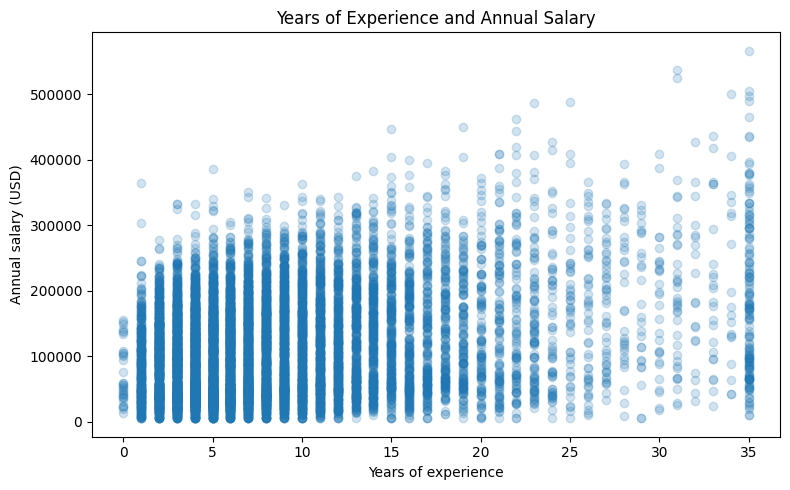

In [115]:
# Scatter plot: years of experience and annual salary

plt.figure(figsize=(8, 5))
plt.scatter(df["years_of_experience"], df["annual_salary_usd"], alpha=0.2)
plt.title("Years of Experience and Annual Salary")
plt.xlabel("Years of experience")
plt.ylabel("Annual salary (USD)")
plt.tight_layout()
plt.show()

### Career and salary interpretation

Years of experience shows the clearest relationship with annual salary. In contrast, the correlations between salary and AI-specific variables such as `num_skills`, `num_ai_tools`, and `avg_usage_frequency` are very weak.

Employees with AI-related promotions show only slightly higher average salary growth, while their average salary is not higher in this dataset. The difference is small, so it should not be interpreted as strong evidence of an AI-related salary premium.

# 6. Burnout Analysis

This section explores burnout levels and checks whether burnout is associated with AI usage, productivity, job satisfaction, or work-life balance.

Unlike the previous version of this analysis, `No burnout` is now treated as a valid category rather than missing data.

In [116]:
# Display burnout level distribution

burnout_counts = df["burnout_level"].value_counts(normalize=True).mul(100).round(2)
burnout_counts

burnout_level
Mild         34.65
Moderate     30.86
No burnout   20.12
Severe       14.37
Name: proportion, dtype: float64

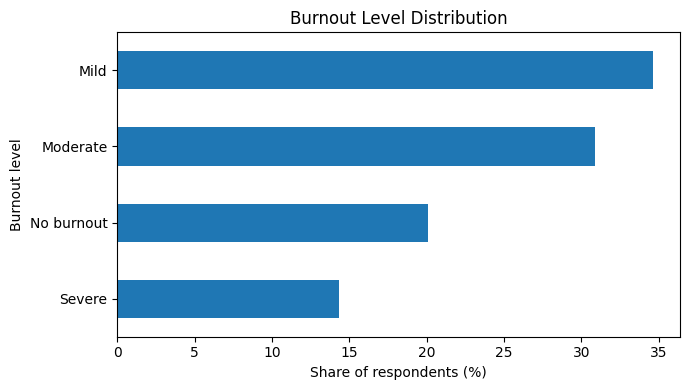

In [117]:
# Visualize burnout level distribution

burnout_counts.sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Burnout Level Distribution")
plt.xlabel("Share of respondents (%)")
plt.ylabel("Burnout level")
plt.tight_layout()
plt.show()

In [118]:
# Compare key metrics by burnout level

burnout_summary = df.groupby("burnout_level")[
    ["avg_usage_frequency", "job_satisfaction_score", "work_life_balance_score",
     "avg_productivity_change_pct", "annual_salary_usd"]
].mean().round(2)

burnout_summary

,avg_usage_frequency,job_satisfaction_score,work_life_balance_score,avg_productivity_change_pct,annual_salary_usd
burnout_level,,,,,
No burnout,3.42,3.65,3.50,30.08,112321.13
Mild,3.44,3.61,3.47,30.13,112193.77
Moderate,3.43,3.63,3.49,30.36,112220.90
Severe,3.48,3.64,3.48,30.28,115551.71


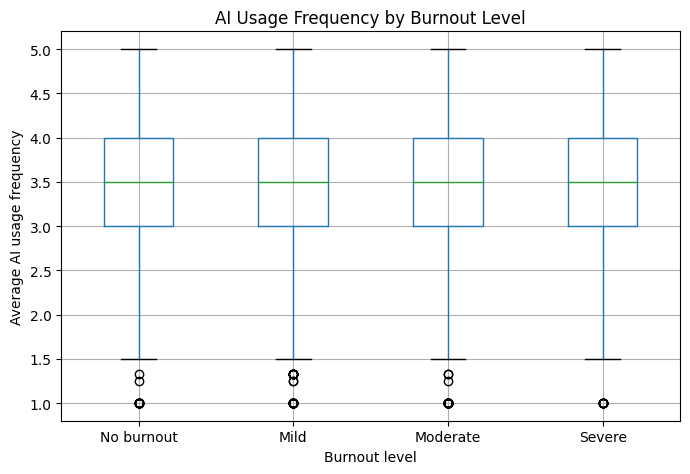

In [119]:
# Visualize AI usage frequency by burnout level

df.boxplot(
    column="avg_usage_frequency",
    by="burnout_level",
    figsize=(7, 5)
)

plt.title("AI Usage Frequency by Burnout Level")
plt.suptitle("")
plt.xlabel("Burnout level")
plt.ylabel("Average AI usage frequency")
plt.tight_layout()
plt.show()

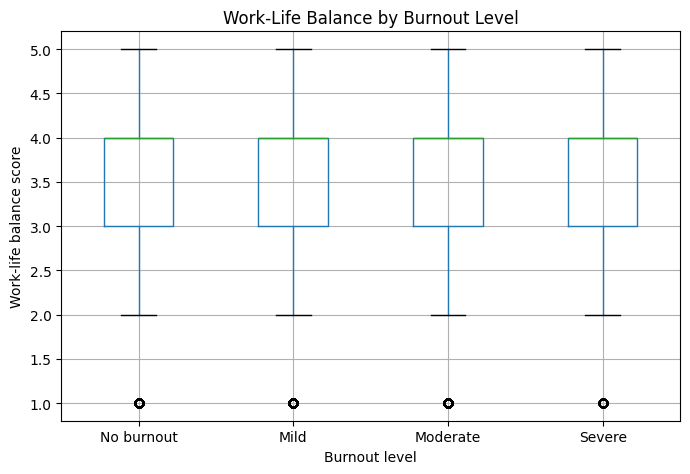

In [120]:
# Visualize work-life balance by burnout level

df.boxplot(
    column="work_life_balance_score",
    by="burnout_level",
    figsize=(7, 5)
)
plt.title("Work-Life Balance by Burnout Level")
plt.suptitle("")
plt.xlabel("Burnout level")
plt.ylabel("Work-life balance score")
plt.tight_layout()
plt.show()

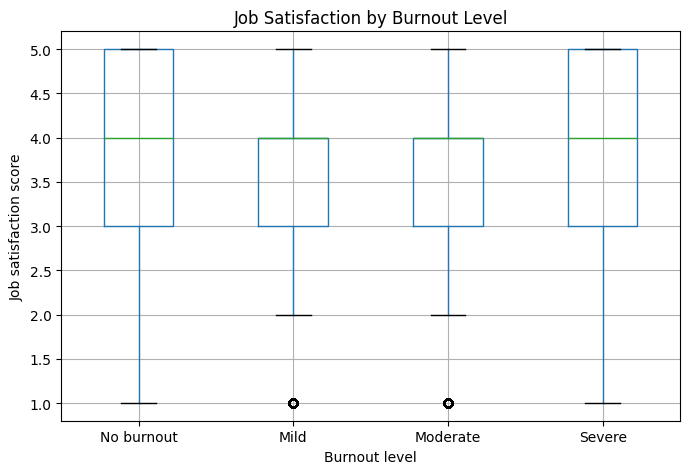

In [121]:
# Visualize job satisfaction by burnout level

df.boxplot(
    column="job_satisfaction_score",
    by="burnout_level",
    figsize=(7, 5)
)
plt.title("Job Satisfaction by Burnout Level")
plt.suptitle("")
plt.xlabel("Burnout level")
plt.ylabel("Job satisfaction score")
plt.tight_layout()
plt.show()

### Burnout interpretation

After replacing empty burnout values with `No burnout`, burnout can be analyzed as a complete categorical variable.

The largest categories are Mild and Moderate burnout, while No burnout represents around one fifth of the dataset. Severe burnout is the smallest category.

However, the group averages across burnout levels are still very similar. Burnout does not show a strong visible relationship with AI usage frequency, productivity change, job satisfaction, or work-life balance in this dataset.

This is an important analytical finding: the burnout variable is now complete, but the expected workplace relationships remain weak.

# 7. Fear of AI Replacement

This section explores employee concern about AI replacing jobs.

In [122]:
# Display distribution of AI job replacement fear

fear_counts = df["ai_job_replacement_fear"].value_counts(normalize=True).mul(100).round(2)
fear_counts

ai_job_replacement_fear
Neutral           30.69
Unlikely          28.20
Somewhat likely   18.04
Very unlikely     15.37
Very likely        7.70
Name: proportion, dtype: float64

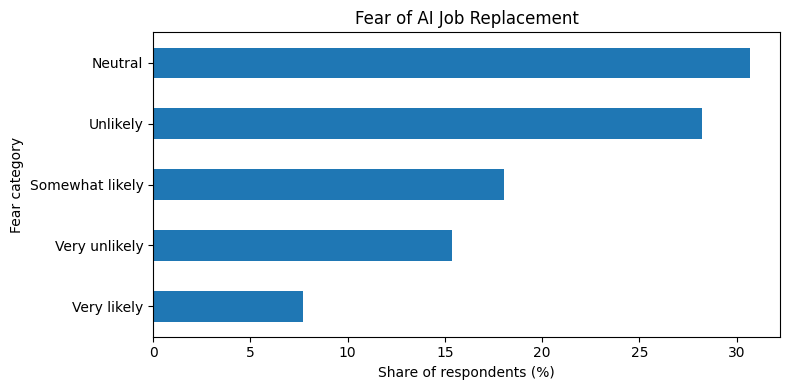

In [123]:
# Visualize AI replacement fear distribution

fear_counts.sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Fear of AI Job Replacement")
plt.xlabel("Share of respondents (%)")
plt.ylabel("Fear category")
plt.tight_layout()
plt.show()

In [124]:
# Compare AI replacement fear by education level

fear_by_education = pd.crosstab(
    df["education_level"],
    df["ai_job_replacement_fear"],
    normalize="index"
).mul(100).round(2)

fear_by_education

ai_job_replacement_fear,Neutral,Somewhat likely,Unlikely,Very likely,Very unlikely
education_level,,,,,
Bachelor's,30.64,18.24,28.26,7.31,15.55
High School,31.09,16.72,30.50,7.33,14.37
Master's,30.48,17.25,28.55,7.81,15.91
PhD,31.21,19.13,27.72,8.19,13.76
Self-taught / Bootcamp,30.87,19.16,27.06,7.85,15.07


In [125]:
# Compare AI replacement fear by industry

fear_by_industry = pd.crosstab(
    df["industry"],
    df["ai_job_replacement_fear"],
    normalize="index"
).mul(100).round(2)

fear_by_industry

ai_job_replacement_fear,Neutral,Somewhat likely,Unlikely,Very likely,Very unlikely
industry,,,,,
Agriculture,28.98,17.14,33.06,8.16,12.65
Automotive,30.52,17.73,26.74,8.43,16.57
Consulting,29.91,17.09,28.48,9.97,14.56
E-commerce,29.80,18.30,29.80,7.70,14.40
Education,32.84,17.48,27.08,7.78,14.82
Energy,33.52,15.34,27.27,5.40,18.47
Finance & Banking,31.14,18.60,27.31,8.42,14.54
Government,32.38,16.08,27.75,7.27,16.52
Healthcare,30.87,19.78,28.46,6.79,14.10


### Fear of AI replacement interpretation

Most respondents fall into the neutral or unlikely categories. Very likely fear of AI replacement is the smallest category.

Differences across education levels and industries exist, but they are not very strong. This suggests that fear of AI replacement is present in the dataset, but it does not vary dramatically across the groups inspected here.

# 8. Correlation Analysis

Correlation analysis helps identify whether numerical variables move together. This is especially important before deciding whether predictive modeling would be meaningful.

In [126]:
# Generate correlation matrix for numerical variables

numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

corr_matrix.round(3)

,survey_year,age,years_of_experience,annual_salary_usd,salary_change_yoy_pct,job_satisfaction_score,work_life_balance_score,num_skills,weekly_learning_hours,ai_bias_concern_level,data_privacy_concern_level,num_ai_tools,avg_usage_frequency,avg_productivity_change_pct,avg_tool_satisfaction
survey_year,1.00,0.01,-0.01,-0.01,0.01,0.01,0.00,-0.00,-0.01,0.01,0.01,-0.01,-0.00,-0.01,-0.00
age,0.01,1.00,-0.01,-0.00,-0.01,0.01,-0.00,0.01,0.00,-0.01,-0.01,-0.01,0.00,-0.00,-0.02
years_of_experience,-0.01,-0.01,1.00,0.29,-0.00,0.01,-0.01,-0.01,0.00,-0.00,0.01,0.01,-0.01,0.00,0.00
annual_salary_usd,-0.01,-0.00,0.29,1.00,0.01,0.01,-0.01,0.00,-0.01,0.01,-0.00,0.01,0.00,0.01,-0.01
salary_change_yoy_pct,0.01,-0.01,-0.00,0.01,1.00,0.01,0.01,-0.01,0.01,-0.01,-0.00,-0.02,0.01,0.00,-0.01
job_satisfaction_score,0.01,0.01,0.01,0.01,0.01,1.00,0.00,-0.01,-0.00,-0.00,-0.01,-0.01,0.00,0.01,0.00
work_life_balance_score,0.00,-0.00,-0.01,-0.01,0.01,0.00,1.00,-0.00,0.01,-0.00,-0.01,-0.00,-0.01,0.03,0.02
num_skills,-0.00,0.01,-0.01,0.00,-0.01,-0.01,-0.00,1.00,-0.02,-0.00,-0.01,-0.00,0.01,-0.02,-0.01
weekly_learning_hours,-0.01,0.00,0.00,-0.01,0.01,-0.00,0.01,-0.02,1.00,0.00,0.00,-0.00,0.01,0.00,-0.00
ai_bias_concern_level,0.01,-0.01,-0.00,0.01,-0.01,-0.00,-0.00,-0.00,0.00,1.00,-0.02,0.01,-0.00,-0.01,-0.00


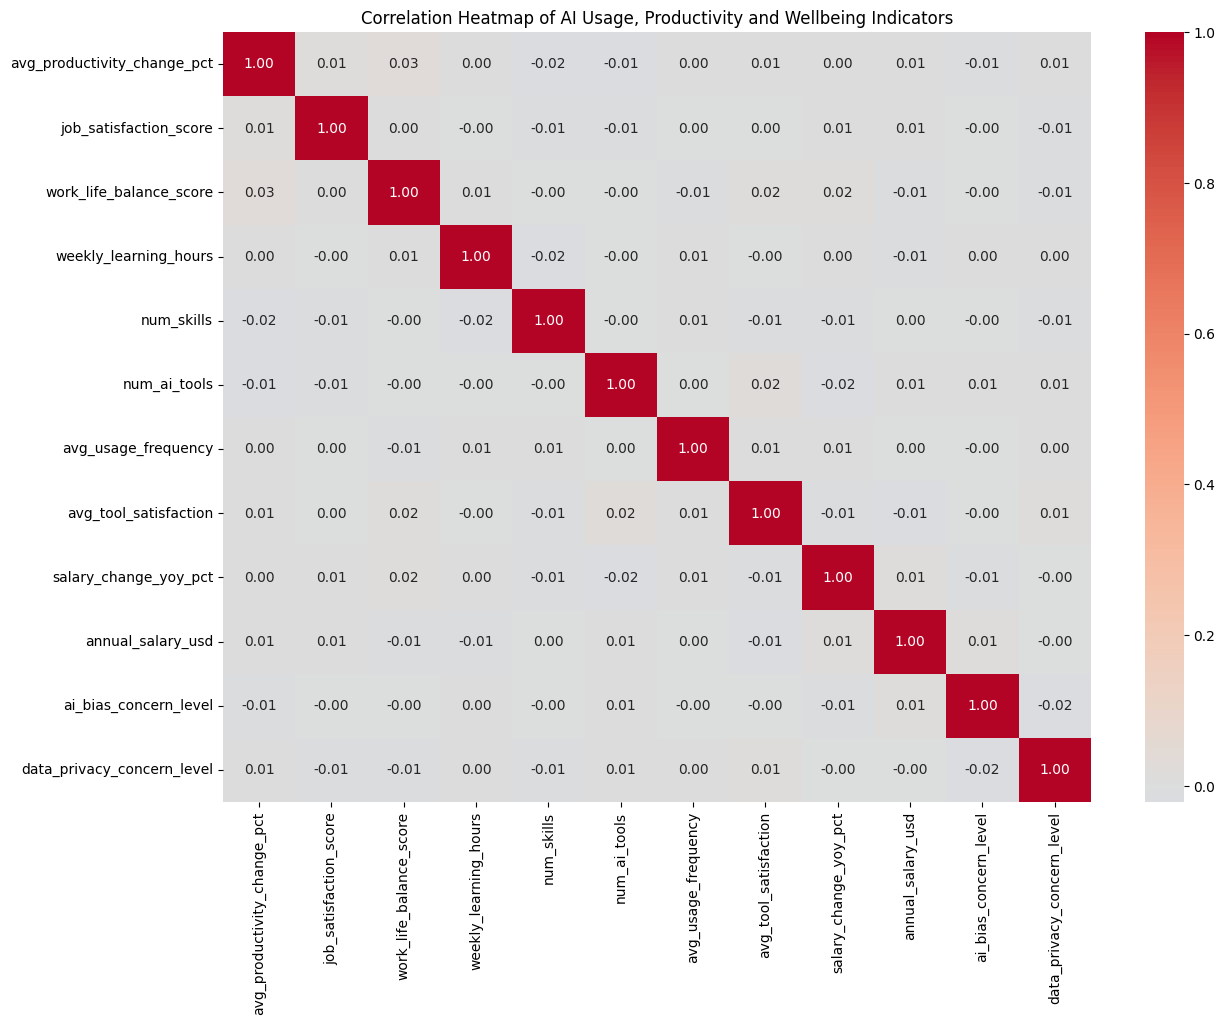

In [127]:
# Visualize correlation heatmap with matplotlib

corr_cols = [
    "avg_productivity_change_pct",
    "job_satisfaction_score",
    "work_life_balance_score",
    "weekly_learning_hours",
    "num_skills",
    "num_ai_tools",
    "avg_usage_frequency",
    "avg_tool_satisfaction",
    "salary_change_yoy_pct",
    "annual_salary_usd",
    "ai_bias_concern_level",
    "data_privacy_concern_level"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of AI Usage, Productivity and Wellbeing Indicators")
plt.show()

In [128]:
# Identify the strongest absolute correlations between numerical variables

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

corr_pairs.sort_values("abs_correlation", ascending=False).head(10)

,feature_1,feature_2,correlation,abs_correlation
33,years_of_experience,annual_salary_usd,0.29,0.29
103,work_life_balance_score,avg_productivity_change_pct,0.03,0.03
29,age,avg_tool_satisfaction,-0.02,0.02
118,num_skills,avg_productivity_change_pct,-0.02,0.02
179,num_ai_tools,avg_tool_satisfaction,0.02,0.02
145,ai_bias_concern_level,data_privacy_concern_level,-0.02,0.02
71,salary_change_yoy_pct,num_ai_tools,-0.02,0.02
113,num_skills,weekly_learning_hours,-0.02,0.02
104,work_life_balance_score,avg_tool_satisfaction,0.02,0.02
66,salary_change_yoy_pct,work_life_balance_score,0.02,0.02


### Correlation interpretation

Most numerical relationships are very weak. The clearest relationship is between years of experience and annual salary, which is plausible.

However, many expected relationships are close to zero, including:

- AI usage frequency and productivity change,
- number of AI tools and productivity change,
- AI skills and salary,
- productivity change and salary growth.

It limits how strongly we can interpret the analytical findings.

# 9. Data Quality Assessment

The EDA reveals several limitations:

- many group averages are very similar,
- most correlations between key workplace variables are weak,
- burnout does not clearly relate to satisfaction or work-life balance,
- AI usage does not clearly relate to productivity change,
- AI skills do not clearly relate to salary.

The updated burnout preprocessing improves interpretability because `No burnout` is now treated as a valid category. However, it does not change the broader observation that many expected relationships remain weak.

These patterns suggest that some variables may have been generated independently or with limited real-world dependency structure.

For this reason, the dataset is useful for practicing EDA and discussing AI adoption themes, but it should not be used to make strong real-world claims.

# 10. Conclusion

This EDA explored AI adoption, productivity, career development, burnout, and fear of AI replacement.

Key findings:

- The dataset is strongly represented by technology-related industries and roles.
- Respondents report active use of AI tools and AI-related learning.
- Average productivity change is positive, but it is not clearly associated with AI usage frequency.
- Years of experience is more clearly related to salary than AI-specific variables.
- Burnout information is now complete after treating empty burnout values as `No burnout`.
- Burnout levels show surprisingly similar averages across key workplace indicators.
- Fear of AI replacement is present but does not vary dramatically across education or industry groups.
- The weak relationships between many variables suggest important data quality limitations.

Overall, this dataset is best used as a supplementary EDA case study rather than as the main source for predictive modeling.